# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2950s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

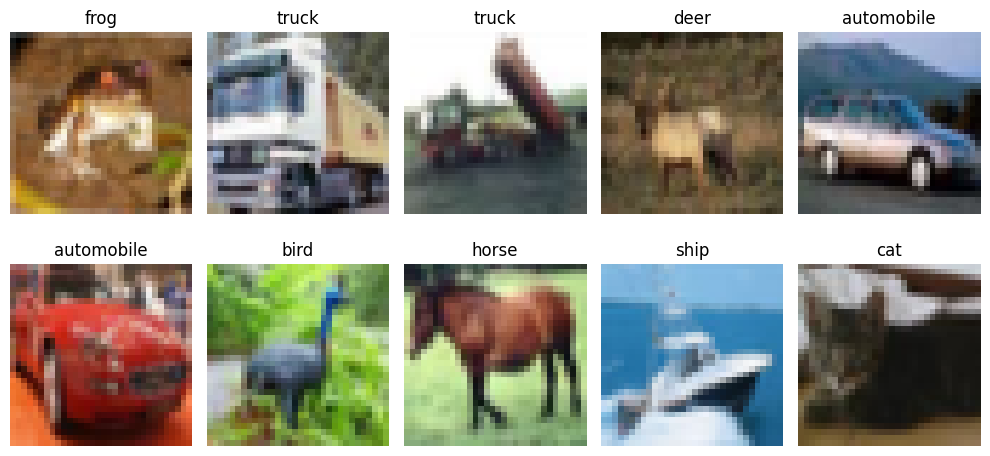

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.2712 - loss: 1.9915 - val_accuracy: 0.3198 - val_loss: 1.8737
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3204 - loss: 1.8630 - val_accuracy: 0.3736 - val_loss: 1.7550
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3369 - loss: 1.8179 - val_accuracy: 0.3734 - val_loss: 1.7410
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3500 - loss: 1.7806 - val_accuracy: 0.3960 - val_loss: 1.7370
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3605 - loss: 1.7565 - val_accuracy: 0.3898 - val_loss: 1.7244
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3736 - loss: 1.7306 - val_accuracy: 0.4094 - val_loss: 1.6871
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3789 - loss: 1.7164 - val_accuracy: 0.4186 - val_loss: 1.6634
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3832 - loss: 1.7011 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4218 - loss: 1.6203
ANN Test Accuracy: 0.42179998755455017


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 111ms/step - accuracy: 0.4654 - loss: 1.4986 - val_accuracy: 0.5396 - val_loss: 1.2707
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.6082 - loss: 1.1201 - val_accuracy: 0.5872 - val_loss: 1.1579
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.6682 - loss: 0.9439 - val_accuracy: 0.6120 - val_loss: 1.1245
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7078 - loss: 0.8348 - val_accuracy: 0.6818 - val_loss: 0.9255
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.7403 - loss: 0.7438 - val_accuracy: 0.7172 - val_loss: 0.8214
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.7666 - loss: 0.6626 - val_accuracy: 0.6946 - val_loss: 0.9136
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.7880 - loss: 0.5980 - val_accuracy: 0.6132 - val_loss: 1.3536
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 109ms/step - accuracy: 0.8094 - loss: 0

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7085 - loss: 0.9606
CNN Test Accuracy: 0.7085000276565552


## 📈 Compare Learning Curves

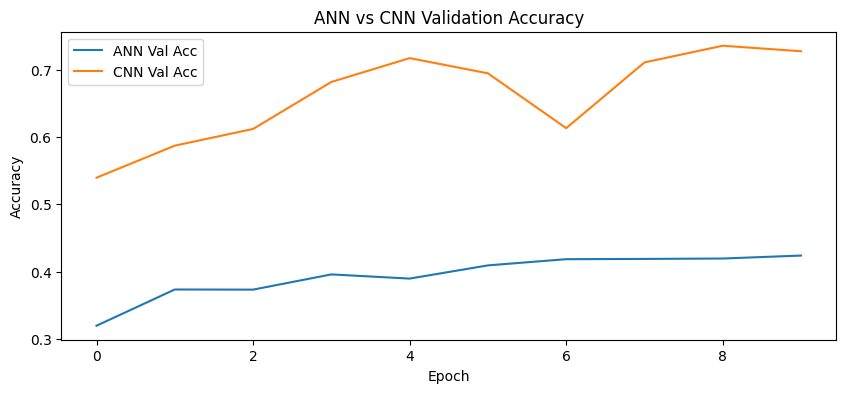

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3),padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)
aug_history=aug_cnn_model.fit(x_train_norm,y_train,epochs=10,validation_split=0.1,batch_size=64)
aug_test_loss,aug_test_acc=aug_cnn_model.evaluate(x_test_norm,y_test,verbose=0)
print("Augmented CNN Test Accuracy: ",round(aug_test_acc,4))

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 145ms/step - accuracy: 0.3561 - loss: 1.7906 - val_accuracy: 0.4568 - val_loss: 1.4730
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 146ms/step - accuracy: 0.4403 - loss: 1.5507 - val_accuracy: 0.5250 - val_loss: 1.3403
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 144ms/step - accuracy: 0.4839 - loss: 1.4434 - val_accuracy: 0.5634 - val_loss: 1.2121
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 144ms/step - accuracy: 0.5116 - loss: 1.3703 - val_accuracy: 0.5928 - val_loss: 1.1632
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 145ms/step - accuracy: 0.5344 - loss: 1.3197 - val_accuracy: 0.5886 - val_loss: 1.1344
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 144ms/step - accuracy: 0.5447 - loss: 1.2867 - val_accuracy: 0.6056 - val_loss: 1.1331
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 144ms/step - accuracy: 0.5564 - loss: 1.2547 - val_accuracy: 0.6430 - val_loss: 1.0231
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 143ms/step - accuracy: 0.5692 -

# 📊 Final Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN(Baseline)", "CNN(baseline)","Augmented CNN"],
    "Test Accuracy": [round(ann_test_acc,4),round(cnn_test_acc,4),round(aug_test_acc,4)]
})
comparison

,Model,Test Accuracy
0,ANN(Baseline),0.4218
1,CNN(baseline),0.7085
2,Augmented CNN,0.6034


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

**Task 1: Increasing ANN Layers and Observing Performance**

We add an extra dense layer to the original ANN. This gives the neywork more capacity to learn. However, more layers also risk overfitting if not controlled with Dropout. Comparing accuracy before and after helps us understand the trade-offs.

>Original ANN: 512->Dropout->Dense(256)->Dense(10)

>Deeper ANN: Dense(512)->Dropout->Dense(256)->Dropout->Dense(128)->Dense(10)

In [16]:
deeper_ann=models.Sequential([layers.Dense(512,activation='relu',input_shape=(3072,)),
                              layers.Dropout(0.3),
                              layers.Dense(256,activation='relu'),
                              layers.Dropout(0.3),
                              layers.Dense(128,activation='relu'),
                              layers.Dense(10,activation='softmax')])
deeper_ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
deeper_ann_history=deeper_ann.fit(x_train_flat,y_train,epochs=10,validation_split=0.1,batch_size=64,verbose=1)
_,deeper_ann_acc=deeper_ann.evaluate(x_test_flat,y_test,verbose=0)
print(f"\nOriginal ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"Deeper ANN Test Accuracy: {deeper_ann_acc:.4f}")
print(f"Difference: {(deeper_ann_acc-ann_test_acc)*100:+.2f} percentage points")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.2393 - loss: 2.0422 - val_accuracy: 0.3148 - val_loss: 1.8760
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2948 - loss: 1.9159 - val_accuracy: 0.3372 - val_loss: 1.8474
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3107 - loss: 1.8750 - val_accuracy: 0.3502 - val_loss: 1.8170
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3241 - loss: 1.8430 - val_accuracy: 0.3678 - val_loss: 1.7711
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3325 - loss: 1.8194 - val_accuracy: 0.3726 - val_loss: 1.7525
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3420 - loss: 1.7976 - val_accuracy: 0.3812 - val_loss: 1.7375
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3456 - loss: 1.7882 - val_accuracy: 0.3742 - val_loss: 1.7443
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3487 - loss: 1.7795 - 

**Tasks 2,3,4,5: Improved CNN, 20 Epochs and EarlyStopping**

We implement all the other three tasks in one improved model.

EarlyStopping: it's a callback function that watches the validation loss. It helps save time and prevents overfitting.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
improved_cnn=models.Sequential([layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
                                layers.BatchNormalization(),
                                layers.MaxPooling2D((2,2)),
                                layers.Conv2D(64,(3,3),activation='relu',padding='same'),
                                layers.BatchNormalization(),
                                layers.MaxPooling2D((2,2)),
                                layers.Conv2D(128,(3,3),activation='relu',padding='same'),
                                layers.BatchNormalization(),
                                layers.Flatten(),
                                layers.Dense(256,activation='relu'),
                                layers.Dropout(0.4),
                                layers.Dense(128,activation='relu'),
                                layers.Dropout(0.3),
                                layers.Dense(10,activation='softmax')])
improved_cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
improved_cnn_history=improved_cnn.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,batch_size=64,callbacks=[early_stop],verbose=1)
_,improved_cnn_acc=improved_cnn.evaluate(x_test_norm,y_test,verbose=0)
print(f"\nBaseline CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"Improved CNN Test Accuracy: {improved_cnn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 207ms/step - accuracy: 0.4343 - loss: 1.6194 - val_accuracy: 0.5342 - val_loss: 1.3865
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 196s 199ms/step - accuracy: 0.6065 - loss: 1.1418 - val_accuracy: 0.5286 - val_loss: 1.3532
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 205ms/step - accuracy: 0.6754 - loss: 0.9464 - val_accuracy: 0.6760 - val_loss: 0.9559
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 203ms/step - accuracy: 0.7203 - loss: 0.8138 - val_accuracy: 0.6554 - val_loss: 1.0041
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 208ms/step - accuracy: 0.7643 - loss: 0.6937 - val_accuracy: 0.7250 - val_loss: 0.8148
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 194s 198ms/step - accuracy: 0.7963 - loss: 0.5988 - val_accuracy: 0.7410 - val_loss: 0.7803
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 199ms/step - accuracy: 0.8263 - loss: 0.5096 - val_accuracy: 0.6888 - val_loss: 0.9783
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 199ms/step - accuracy: 0.8516 -

**Final Validation Accuracy Chart(All Variants)**

We visualize the accuracy across all 5 model variants that were trained: ANN, Deeper ANN, Baseline CNN, Improved CNN and augmented CNN.

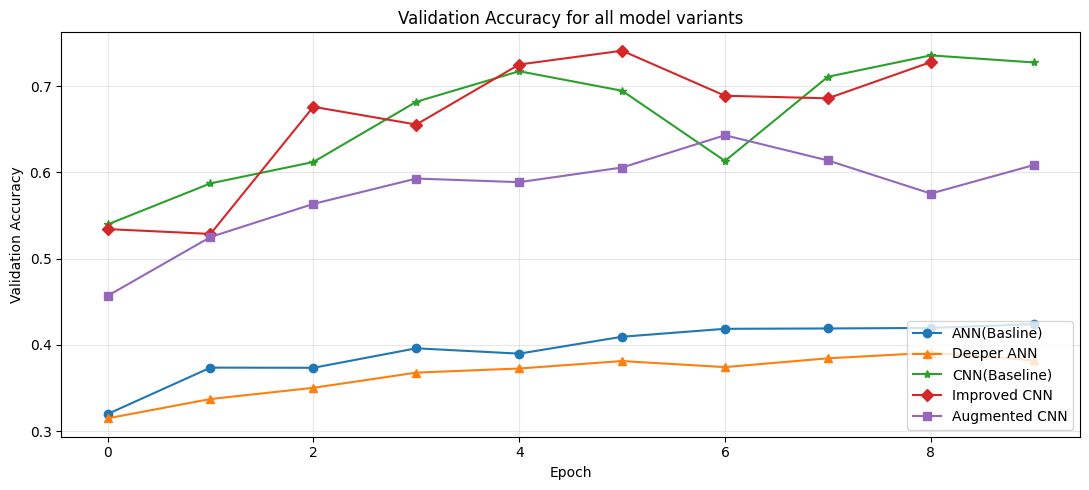

In [20]:
plt.figure(figsize=(11,5))
plt.plot(ann_history.history['val_accuracy'],label='ANN(Basline)',marker='o')
plt.plot(deeper_ann_history.history['val_accuracy'],label='Deeper ANN',marker='^')
plt.plot(cnn_history.history['val_accuracy'],label='CNN(Baseline)',marker='*')
plt.plot(improved_cnn_history.history['val_accuracy'],label='Improved CNN',marker='D')
plt.plot(aug_history.history['val_accuracy'],label='Augmented CNN',marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy for all model variants')
plt.legend(loc='lower right')
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

**Final Comparison Table**

This is a summary of all the models trained in this notebook with their test accuracy.

In [22]:
final_comparison=pd.DataFrame({"Model":["ANN(Basline)","Deeper ANN","CNN(Baseline)","Improved CNN","Augmented CNN"],
                               "Test Accuracy":[round(ann_test_acc,4),round(deeper_ann_acc,4),round(cnn_test_acc,4),round(improved_cnn_acc,4),round(aug_test_acc,4)],
                               })
print("Best Model: ",final_comparison.loc[final_comparison['Test Accuracy'].idxmax(),'Model'])

final_comparison

Best Model:  Improved CNN


,Model,Test Accuracy
0,ANN(Basline),0.4218
1,Deeper ANN,0.3982
2,CNN(Baseline),0.7085
3,Improved CNN,0.7229
4,Augmented CNN,0.6034


# ✅ Conclusion
- **ANN works**, but ignores image structure, accuracy is limited.
-Deeper ANN adds one more layer, marginal gains but same structural limitation.
- **CNN extracts spatial features**, so it performs significantly better. Improved CNN pushes the accuracy furthur.

  -Data Augmentation reduces overfitting by showing model varied versions of each image.

- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

> Note: Although Data Augmentation generally improves generalization, in this instance the augmented CNN achieved lower accuracy than the improved CNN. This could be due to augmentation settings, limited training time or early stopping. With further hyperparameter tuning, augmentation may improve performance.